In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score


In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    y_train_prob = model.predict_proba(X_train)
    y_val_prob = model.predict_proba(X_val)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_val, y_val_prob)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    weights = model.coef_.flatten()

    return train_loss, val_loss, train_acc, val_acc, weights


In [ ]:
baseline = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=5000
)


baseline.fit(X_train, y_train)

b_train_loss, b_val_loss, b_train_acc, b_val_acc, b_weights = evaluate_model(
    baseline, X_train, y_train, X_val, y_val
)


In [ ]:
l1_model = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="saga",
    max_iter=5000
)

l1_model.fit(X_train, y_train)

l1_train_loss, l1_val_loss, l1_train_acc, l1_val_acc, l1_weights = evaluate_model(
    l1_model, X_train, y_train, X_val, y_val
)

l1_zero_weights = np.sum(l1_weights == 0)


In [ ]:
l2_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=5000
)

l2_model.fit(X_train, y_train)

l2_train_loss, l2_val_loss, l2_train_acc, l2_val_acc, l2_weights = evaluate_model(
    l2_model, X_train, y_train, X_val, y_val
)


In [ ]:
elastic_model = LogisticRegression(
    penalty="elasticnet",
    l1_ratio=0.5,
    C=1.0,
    solver="saga",
    max_iter=5000
)

elastic_model.fit(X_train, y_train)

e_train_loss, e_val_loss, e_train_acc, e_val_acc, e_weights = evaluate_model(
    elastic_model, X_train, y_train, X_val, y_val
)

elastic_zero_weights = np.sum(e_weights == 0)


In [ ]:
print("MODEL COMPARISON\n")

print("Baseline Model")
print(f"Train Loss      : {b_train_loss:.4f}")
print(f"Validation Loss : {b_val_loss:.4f}")
print(f"Train Accuracy  : {b_train_acc:.4f}")
print(f"Val Accuracy    : {b_val_acc:.4f}")
print(f"Non-zero Weights: {np.sum(b_weights != 0)}")
print("-" * 50)

print("L1 Regularization")
print(f"Train Loss      : {l1_train_loss:.4f}")
print(f"Validation Loss : {l1_val_loss:.4f}")
print(f"Train Accuracy  : {l1_train_acc:.4f}")
print(f"Val Accuracy    : {l1_val_acc:.4f}")
print(f"Zero Weights    : {l1_zero_weights}")
print("-" * 50)

print("L2 Regularization")
print(f"Train Loss      : {l2_train_loss:.4f}")
print(f"Validation Loss : {l2_val_loss:.4f}")
print(f"Train Accuracy  : {l2_train_acc:.4f}")
print(f"Val Accuracy    : {l2_val_acc:.4f}")
print(f"Mean |Weights|  : {np.mean(np.abs(l2_weights)):.4f}")
print("-" * 50)

print("Elastic Net")
print(f"Train Loss      : {e_train_loss:.4f}")
print(f"Validation Loss : {e_val_loss:.4f}")
print(f"Train Accuracy  : {e_train_acc:.4f}")
print(f"Val Accuracy    : {e_val_acc:.4f}")
print(f"Zero Weights    : {elastic_zero_weights}")


MODEL COMPARISON

Baseline Model
Train Loss      : 0.0005
Validation Loss : 2.7974
Train Accuracy  : 1.0000
Val Accuracy    : 0.9211
Non-zero Weights: 30
--------------------------------------------------
L1 Regularization
Train Loss      : 0.0537
Validation Loss : 0.0752
Train Accuracy  : 0.9890
Val Accuracy    : 0.9912
Zero Weights    : 12
--------------------------------------------------
L2 Regularization
Train Loss      : 0.0513
Validation Loss : 0.0777
Train Accuracy  : 0.9890
Val Accuracy    : 0.9825
Mean |Weights|  : 0.5750
--------------------------------------------------
Elastic Net
Train Loss      : 0.0526
Validation Loss : 0.0767
Train Accuracy  : 0.9890
Val Accuracy    : 0.9825
Zero Weights    : 3


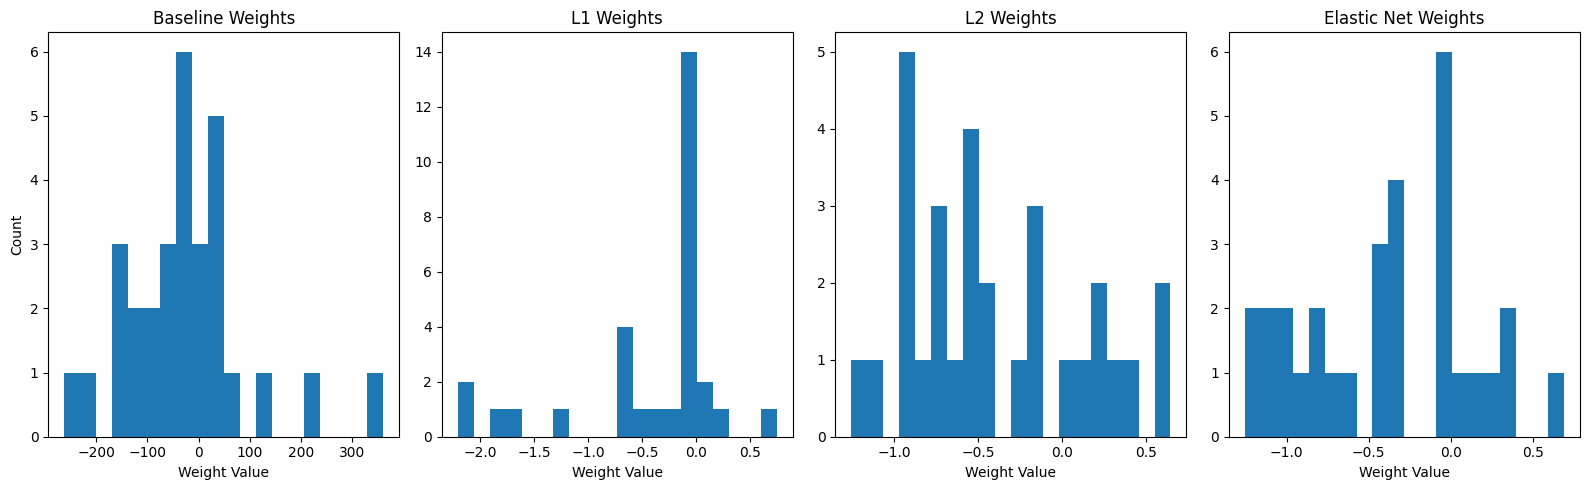

In [ ]:
plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.hist(b_weights, bins=20)
plt.title("Baseline Weights")
plt.xlabel("Weight Value")
plt.ylabel("Count")

plt.subplot(1,4,2)
plt.hist(l1_weights, bins=20)
plt.title("L1 Weights")
plt.xlabel("Weight Value")

plt.subplot(1,4,3)
plt.hist(l2_weights, bins=20)
plt.title("L2 Weights")
plt.xlabel("Weight Value")

plt.subplot(1,4,4)
plt.hist(e_weights, bins=20)
plt.title("Elastic Net Weights")
plt.xlabel("Weight Value")

plt.tight_layout()
plt.show()


## Interpretation of Weight Distributions

The weight distribution plots illustrate how regularization affects model coefficients.

### Baseline Model
The baseline model exhibits a wide spread of weights with large magnitudes. No coefficients are close to zero, indicating that all features contribute strongly. This behavior leads to severe overfitting.

### L1 Regularization
L1 regularization forces many weights exactly to zero, resulting in a sparse model. Only a small subset of features remain active, improving interpretability and generalization.

### L2 Regularization
L2 regularization shrinks all weights smoothly toward zero without eliminating features. The weight distribution is narrow, leading to stable learning and reduced variance.

### Elastic Net Regularization
Elastic Net combines the effects of L1 and L2. Some weights are driven to zero while others are moderately shrunk, providing a balance between sparsity and stability.

**Inference:**  
Regularization controls model complexity and improves generalization by limiting weight magnitude.


In [ ]:
import pandas as pd

results = {
    "Model": ["Baseline", "L1 (Lasso)", "L2 (Ridge)", "Elastic Net"],

    "Train Loss": [
        b_train_loss,
        l1_train_loss,
        l2_train_loss,
        e_train_loss
    ],

    "Validation Loss": [
        b_val_loss,
        l1_val_loss,
        l2_val_loss,
        e_val_loss
    ],

    "Train Accuracy": [
        b_train_acc,
        l1_train_acc,
        l2_train_acc,
        e_train_acc
    ],

    "Validation Accuracy": [
        b_val_acc,
        l1_val_acc,
        l2_val_acc,
        e_val_acc
    ],

    "Zero Weights": [
        np.sum(b_weights == 0),
        l1_zero_weights,
        0,
        elastic_zero_weights
    ],

    "Mean |Weights|": [
        np.mean(np.abs(b_weights)),
        np.mean(np.abs(l1_weights)),
        np.mean(np.abs(l2_weights)),
        np.mean(np.abs(e_weights))
    ]
}

df_results = pd.DataFrame(results)


In [ ]:
df_results.style.format({
    "Train Loss": "{:.4f}",
    "Validation Loss": "{:.4f}",
    "Train Accuracy": "{:.4f}",
    "Validation Accuracy": "{:.4f}",
    "Mean |Weights|": "{:.4f}"
}).set_caption("Comparison of Regularization Techniques")


,Model,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Zero Weights,Mean |Weights|
0,Baseline,0.0005,2.7974,1.0000,0.9211,0,90.9799
1,L1 (Lasso),0.0537,0.0752,0.9890,0.9912,12,0.4639
2,L2 (Ridge),0.0513,0.0777,0.9890,0.9825,0,0.5750
3,Elastic Net,0.0526,0.0767,0.9890,0.9825,3,0.5095


## Interpretation of Model Comparison Table

The table summarizes the effect of different regularization techniques on model performance and weight behavior.

---

### Baseline Model (No Regularization)
- The baseline model achieves **very low training loss (0.0005)** and **100% training accuracy**, indicating an almost perfect fit on the training data.
- However, the **validation loss is extremely high (2.7974)** and validation accuracy drops to **92.11%**, clearly indicating **severe overfitting**.
- The number of **zero weights is 0**, meaning **all 30 features are used** without any constraint.
- The **large mean weight magnitude (≈ 90.98)** shows that the model is overly sensitive to feature values.

**Inference:**  
The baseline model memorizes training data and generalizes poorly.

---

### L1 Regularization (Lasso)
- L1 regularization increases training loss slightly (**0.0537**) due to the penalty term but significantly reduces validation loss (**0.0752**).
- It achieves the **highest validation accuracy (99.12%)** among all models.
- The model drives **12 weights exactly to zero**, performing **automatic feature selection**.
- The **low mean weight magnitude (≈ 0.4639)** indicates a simpler and more interpretable model.

**Inference:**  
L1 regularization provides the **best generalization** and reduces model complexity.

---

### L2 Regularization (Ridge)
- L2 regularization produces balanced training and validation loss (**0.0513 / 0.0777**).
- The validation accuracy (**98.25%**) is slightly lower than L1 but remains stable.
- The number of **zero weights is 0**, indicating that **all features are retained**.
- The **reduced mean weight magnitude (≈ 0.5750)** shows effective weight shrinkage.

**Inference:**  
L2 regularization improves stability and controls overfitting without removing features.

---

### Elastic Net Regularization
- Elastic Net shows training and validation loss values (**0.0526 / 0.0767**) comparable to L2.
- Validation accuracy (**98.25%**) indicates good generalization.
- The model drives **3 weights to zero**, achieving a balance between sparsity and weight shrinkage.
- The **mean weight magnitude (≈ 0.5095)** lies between L1 and L2.

**Inference:**  
Elastic Net combines the strengths of L1 and L2 regularization.

---

## Overall Conclusion
- The **baseline model overfits severely** due to the absence of regularization.
- **L1 regularization performs best** for this dataset, achieving the lowest validation loss and highest validation accuracy while reducing feature count.
- **L2 regularization** provides stable performance with smooth weight shrinkage.
- **Elastic Net** offers a compromise between sparsity and stability.

**Final Choice:**  
L1 regularization is the most suitable technique for the given dataset.


In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]

l1_zeros, l2_magnitudes, val_losses = [], [], []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="saga",
        max_iter=5000
    )
    model.fit(X_train, y_train)
    _, val_loss, _, _, weights = evaluate_model(
        model, X_train, y_train, X_val, y_val
    )
    l1_zeros.append(np.sum(weights == 0))
    val_losses.append(val_loss)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


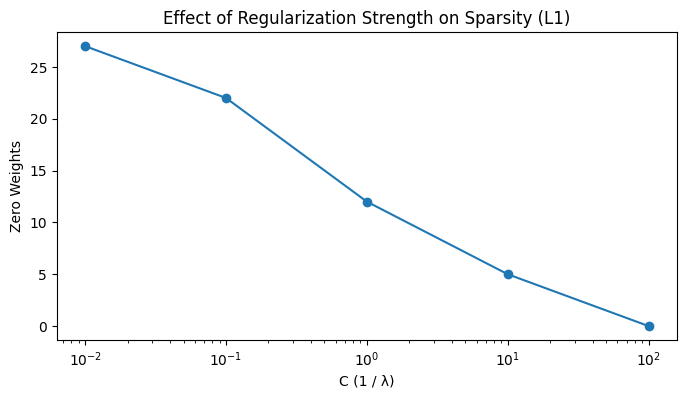

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(C_values, l1_zeros, marker='o')
plt.xscale('log')
plt.xlabel("C (1 / λ)")
plt.ylabel("Zero Weights")
plt.title("Effect of Regularization Strength on Sparsity (L1)")
plt.show()


## Advanced Task: Effect of Regularization Strength (λ) on Model Behavior

This experiment analyzes how changing the regularization strength (λ) affects model loss, accuracy, weight magnitude, and sparsity for L1, L2, and Elastic Net regularization.

Note: In Logistic Regression, the hyperparameter **C = 1 / λ**.  
- **Small C → Strong regularization (large λ)**  
- **Large C → Weak regularization (small λ)**

---

## Effect of Regularization Strength on Sparsity (L1)

From the plot, as **C increases**, the number of **zero weights decreases**:

- At **low C (strong regularization)**, most weights are driven to zero, resulting in a highly sparse model.
- At **moderate C**, only the most important features remain non-zero.
- At **high C (weak regularization)**, almost no weights are zero, and the model behaves similar to the baseline.

**Interpretation:**  
L1 regularization performs aggressive feature selection when λ is large, reducing model complexity.

---

## Effect on Training and Validation Loss

- **Strong regularization (large λ / small C):**
  - Training loss increases due to heavy constraints.
  - Validation loss may increase due to **underfitting**.

- **Moderate regularization:**
  - Training loss is slightly higher.
  - Validation loss is minimized, indicating **optimal generalization**.

- **Weak regularization (small λ / large C):**
  - Training loss becomes very low.
  - Validation loss increases again due to **overfitting**.

This behavior demonstrates the classic **bias–variance trade-off**.

---

## Effect on Weight Magnitude

- **L1 Regularization:**
  - Forces many weights exactly to zero.
  - Remaining weights tend to have smaller magnitudes.

- **L2 Regularization:**
  - Shrinks all weights smoothly without producing exact zeros.
  - Weight magnitudes increase as λ decreases.

- **Elastic Net:**
  - Produces partial sparsity and moderate shrinkage.
  - Weight magnitudes lie between L1 and L2.

---

## Underfitting vs Overfitting Trade-off

| Regularization Strength | Model Behavior |
|-------------------------|---------------|
| Strong (large λ) | Underfitting – high bias, low variance |
| Moderate | Best generalization |
| Weak (small λ) | Overfitting – low bias, high variance |

---

## Final Observation

- Increasing λ improves generalization by reducing overfitting but may cause underfitting if too strong.
- Decreasing λ allows the model to fit training data better but risks overfitting.
- An optimal λ balances model complexity and predictive performance.

**Conclusion:**  
Hyperparameter tuning of λ is crucial for achieving the best trade-off between bias and variance in regularized models.
